# Hands-On: K-Means Clustering pada Data Well Log
## Unsupervised Learning untuk Identifikasi Fasies Litologi **bold text**

---

### Tujuan Pembelajaran
Setelah menyelesaikan hands-on ini, Anda akan mampu:
1. Memahami konsep dasar unsupervised learning dan K-means clustering
2. Memuat dan mengeksplorasi data well log format LAS
3. Melakukan preprocessing data untuk clustering
4. Mengimplementasikan algoritma K-means clustering
5. Menentukan jumlah cluster optimal menggunakan elbow method dan silhouette score
6. Menginterpretasi hasil clustering dalam konteks geologi
7. Memvalidasi hasil clustering dengan formation tops

---

### Dataset
**Well**: South Barrow 18 (SB-18)  
**Lokasi**: Alaska, USA  
**Tahun**: 1980  
**Tipe**: Wildcat well (gas discovery)  
**Kedalaman**: 98 - 2124 ft  
**Sumber**: [USGS Open File Report 00-200](https://certmapper.cr.usgs.gov/data/PubArchives/OF00-200/WELLS/SBAR18/INDEX.HTM)

---
## Part 1: Pengantar Unsupervised Learning

### Apa itu Unsupervised Learning?
Unsupervised learning adalah teknik machine learning dimana algoritma belajar dari data **tanpa label**. Berbeda dengan supervised learning, kita tidak memberitahu algoritma "ini shale", "ini sandstone", dll. Algoritma akan mencari pola dan pengelompokan secara otomatis.

### K-Means Clustering
K-means adalah algoritma clustering yang:
- Membagi data ke dalam K kelompok (cluster)
- Setiap cluster memiliki centroid (titik pusat)
- Data point dikelompokkan ke cluster dengan centroid terdekat

**Cara Kerja:**
1. Tentukan jumlah cluster (K)
2. Inisialisasi K centroid secara random
3. Assign setiap data point ke centroid terdekat
4. Update posisi centroid berdasarkan rata-rata data point di cluster-nya
5. Ulangi langkah 3-4 hingga konvergen

### Aplikasi pada Well Log
- **Fasies identification**: Mengelompokkan zona dengan karakteristik log serupa
- **Reservoir characterization**: Membedakan zona reservoir dan non-reservoir
- **Lithology prediction**: Identifikasi tipe batuan berdasarkan pola log

---
## Part 2: Import Libraries dan Setup

In [ ]:
!pip install lasio

# Data manipulation dan analisis
import pandas as pd
import numpy as np
import os

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

# Well log library
import lasio

# Pengaturan visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Suppres warnings
import warnings
warnings.filterwarnings('ignore')

# load google drive
from google.colab import drive
drive.mount('/content/drive')

print("✓ Libraries berhasil dimuat!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.5 MB/s eta 0:00:00
Mounted at /content/drive
✓ Libraries berhasil dimuat!


---
## Part 3: Load dan Eksplorasi Data

### 3.1 Memuat Data LAS File

In [ ]:
# Load LAS file
BASE_PATH = "/content/drive/MyDrive/Kuliah/Tp 2025 2026/Ganjil/Machine Learning Dalam Geofisika/Materi Kuliah/Materi Fixed"

LAS_PATH  = os.path.join(BASE_PATH, "SB18.LAS")
TOPS_PATH = os.path.join(BASE_PATH, "SB18TOPS.txt")


# las_file = '/mnt/user-data/uploads/SB18.LAS'
las = lasio.read(LAS_PATH)

# ini kalau dari temp drive/files
# las = lasio.read("/content/SB18.LAS")

# Konversi ke DataFrame
df = las.df()
df = df.reset_index()  # Depth menjadi kolom

print(f"Shape data: {df.shape}")
print(f"\nKedalaman: {df['M__DEPTH'].min():.1f} - {df['M__DEPTH'].max():.1f} ft")
print(f"\nKolom yang tersedia:")
print(df.columns.tolist())

Shape data: (4053, 14)

Kedalaman: 98.0 - 2124.0 ft

Kolom yang tersedia:
['M__DEPTH', 'SP', 'GR', 'CALI', 'BITSIZE', 'SFL_A', 'ILM', 'ILD', 'LLD', 'LLS', 'RHOB', 'NPHI', 'DT', 'MUDWGT']


In [ ]:
df.tail(10)

,M__DEPTH,SP,GR,CALI,BITSIZE,SFL_A,ILM,ILD,LLD,LLS,RHOB,NPHI,DT,MUDWGT
4043,2119.5,NaN,NaN,9.2153,8.5,NaN,NaN,NaN,NaN,NaN,2.4810,16.0213,NaN,10.3
4044,2120.0,NaN,NaN,9.1988,8.5,NaN,NaN,NaN,NaN,NaN,2.4884,11.5019,NaN,10.3
4045,2120.5,NaN,NaN,9.1979,8.5,NaN,NaN,NaN,NaN,NaN,2.4961,4.3885,NaN,10.3
4046,2121.0,NaN,NaN,9.2327,8.5,NaN,NaN,NaN,NaN,NaN,2.5018,0.6515,NaN,10.3
4047,2121.5,NaN,NaN,9.2083,8.5,NaN,NaN,NaN,NaN,NaN,2.5139,-0.0823,NaN,10.3
4048,2122.0,NaN,NaN,9.1493,8.5,NaN,NaN,NaN,NaN,NaN,2.5132,-0.0814,NaN,10.3
4049,2122.5,NaN,NaN,9.1637,8.5,NaN,NaN,NaN,NaN,NaN,2.4910,-0.0804,NaN,10.3
4050,2123.0,NaN,NaN,9.1763,8.5,NaN,NaN,NaN,NaN,NaN,2.4299,-0.0795,NaN,10.3
4051,2123.5,NaN,NaN,9.1423,8.5,NaN,NaN,NaN,NaN,NaN,2.3412,-0.0785,NaN,10.3
4052,2124.0,NaN,NaN,9.0960,8.5,NaN,NaN,NaN,NaN,NaN,2.2484,-0.0776,NaN,10.3


In [ ]:
# Informasi detail dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4053 entries, 0 to 4052
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   M__DEPTH  4053 non-null   float64
 1   SP        2815 non-null   float64
 2   GR        3991 non-null   float64
 3   CALI      1209 non-null   float64
 4   BITSIZE   4037 non-null   float64
 5   SFL_A     2811 non-null   float64
 6   ILM       2804 non-null   float64
 7   ILD       2815 non-null   float64
 8   LLD       1157 non-null   float64
 9   LLS       1157 non-null   float64
 10  RHOB      1202 non-null   float64
 11  NPHI      1196 non-null   float64
 12  DT        3994 non-null   float64
 13  MUDWGT    4053 non-null   float64
dtypes: float64(14)
memory usage: 443.4 KB


In [ ]:
# Statistik deskriptif
df.describe()

,M__DEPTH,SP,GR,CALI,BITSIZE,SFL_A,ILM,ILD,LLD,LLS,RHOB,NPHI,DT,MUDWGT
count,4053.000000,2815.000000,3991.000000,1209.000000,4037.000000,2811.000000,2804.000000,2815.000000,1157.000000,1157.000000,1202.000000,1196.000000,3994.000000,4053.000000
mean,1111.000000,-9.342747,85.599445,9.803584,11.105586,22.471020,15.287088,10.231260,14.757087,12.698015,2.465952,32.280368,129.932368,9.413644
std,585.072325,5.203805,13.853348,0.661379,1.727023,23.323648,8.074347,2.827368,7.368572,6.088987,0.063344,6.683816,27.187040,0.425523
min,98.000000,-38.785920,25.296800,8.682400,8.500000,4.319500,7.165900,2.175800,6.046600,5.541100,2.130100,-0.082300,64.420200,8.700000
25%,604.500000,-10.516450,80.508050,9.230200,8.500000,7.926250,10.187925,8.660350,11.172100,9.548200,2.450225,27.003975,108.966650,9.300000
50%,1111.000000,-8.541500,87.072100,9.801100,12.250000,9.742700,11.990750,9.386100,12.805900,10.819600,2.484150,32.316100,125.319435,9.400000
75%,1617.500000,-6.754010,91.808300,10.197400,12.250000,31.314150,17.981900,11.128600,16.109300,14.276300,2.503075,38.112625,151.069592,9.400000
max,2124.000000,6.254000,169.101590,13.856200,12.250000,169.848800,65.265100,48.032400,72.327700,53.768900,2.613100,49.284000,207.715300,10.300000


### 3.2 Memuat Formation Tops

In [ ]:
# Data formation tops
tops_data = {
    'Formation': ['Surficial Deposits/Gubik', 'Torok Formation', 'Pebble Shale Unit', 'Kingak Shale'],
    'Depth_ft': [18.0, 75.0, 1375.0, 1760.0]
}
df_tops = pd.DataFrame(tops_data)

print("Formation Tops:")
print(df_tops)

Formation Tops:
                  Formation  Depth_ft
0  Surficial Deposits/Gubik      18.0
1           Torok Formation      75.0
2         Pebble Shale Unit    1375.0
3              Kingak Shale    1760.0


### 3.3 Handling Missing Values

Dalam data LAS, nilai -999 biasanya menandakan data yang hilang (null value).

In [ ]:
# Replace -999 dengan NaN
df_clean = df.replace(-999, np.nan)

# Cek missing values per kolom
missing_stats = pd.DataFrame({
    'Missing_Count': df_clean.isnull().sum(),
    'Missing_Percentage': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})

print("Missing Value Statistics:")
print(missing_stats[missing_stats['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False))

Missing Value Statistics:
         Missing_Count  Missing_Percentage
LLS               2896               71.45
LLD               2896               71.45
NPHI              2857               70.49
RHOB              2851               70.34
CALI              2844               70.17
ILM               1249               30.82
SFL_A             1242               30.64
SP                1238               30.55
ILD               1238               30.55
GR                  62                1.53
DT                  59                1.46
BITSIZE             16                0.39


### 3.4 Visualisasi Well Log

Mari kita plot beberapa log utama untuk melihat karakteristik sumur.

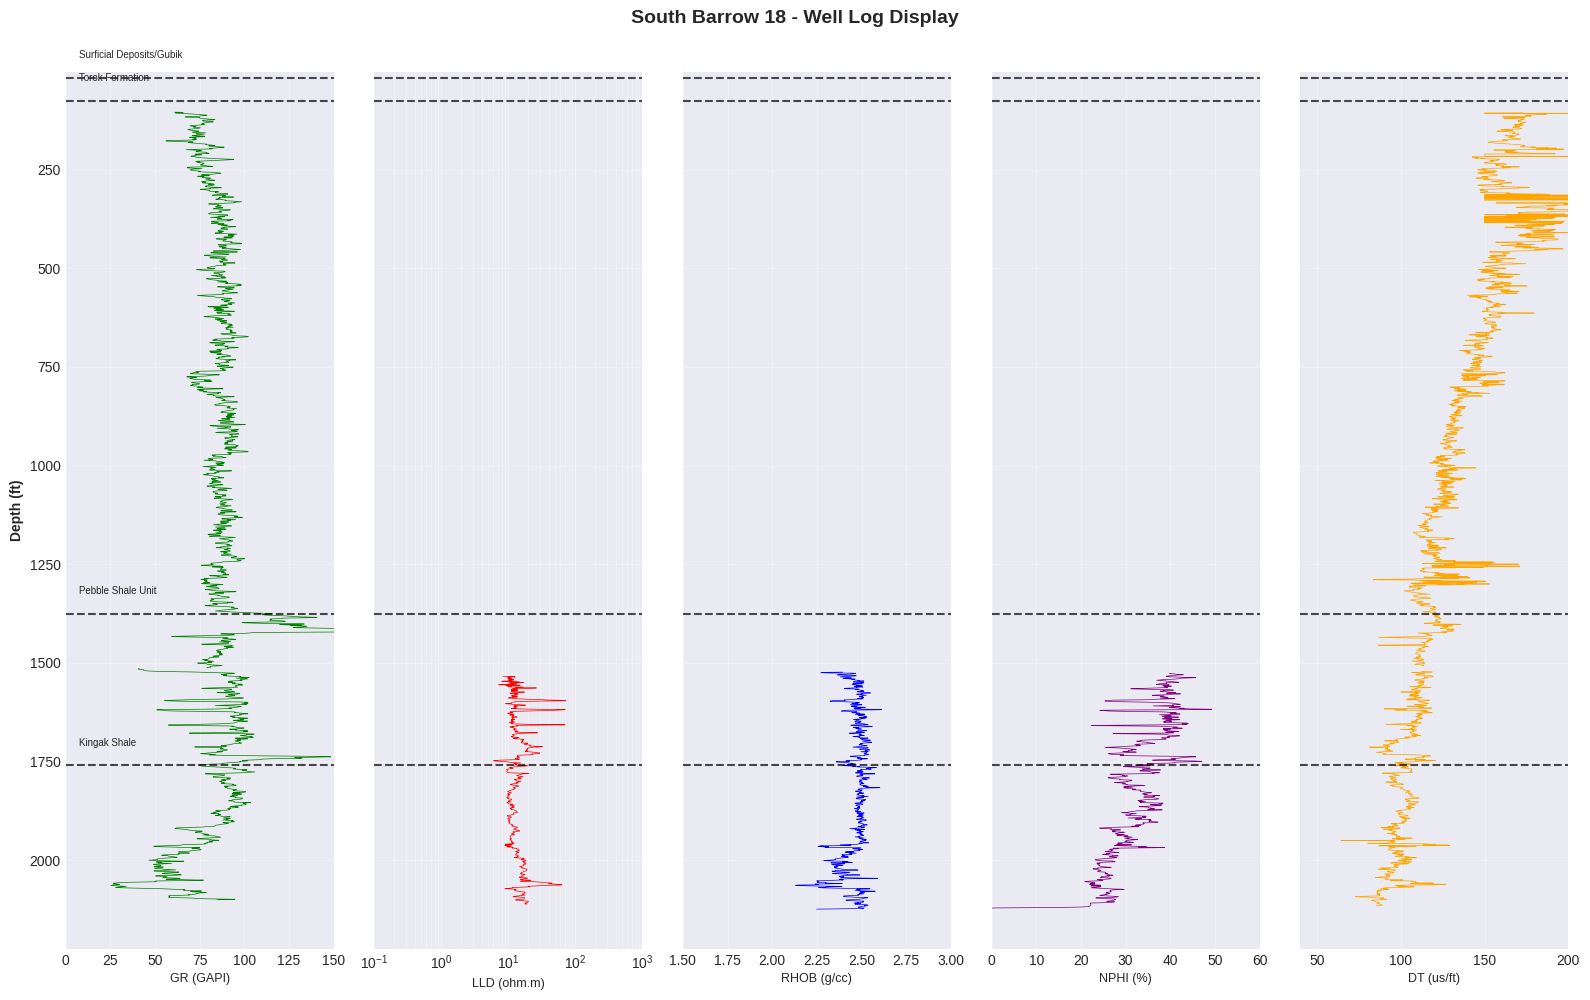

✓ Well log berhasil divisualisasikan!


In [ ]:
# Pilih interval yang menarik (laterolog run: 1534-2100 ft sesuai artikel)
# Tapi kita plot seluruh sumur dulu untuk overview

fig, axes = plt.subplots(1, 5, figsize=(16, 10), sharey=True)
fig.suptitle('South Barrow 18 - Well Log Display', fontsize=14, fontweight='bold', y=0.995)

# Invert y-axis (depth meningkat ke bawah)
depth = df_clean['M__DEPTH']

# Track 1: Gamma Ray
axes[0].plot(df_clean['GR'], depth, 'g-', linewidth=0.5)
axes[0].set_xlabel('GR (GAPI)', fontsize=9)
axes[0].set_xlim(0, 150)
axes[0].set_ylabel('Depth (ft)', fontsize=10, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].invert_yaxis()

# Track 2: Resistivity (LLD)
axes[1].semilogx(df_clean['LLD'], depth, 'r-', linewidth=0.5)
axes[1].set_xlabel('LLD (ohm.m)', fontsize=9)
axes[1].set_xlim(0.1, 1000)
axes[1].grid(True, alpha=0.3, which='both')

# Track 3: Density (RHOB)
axes[2].plot(df_clean['RHOB'], depth, 'b-', linewidth=0.5)
axes[2].set_xlabel('RHOB (g/cc)', fontsize=9)
axes[2].set_xlim(1.5, 3.0)
axes[2].grid(True, alpha=0.3)

# Track 4: Neutron Porosity
axes[3].plot(df_clean['NPHI'], depth, 'purple', linewidth=0.5)
axes[3].set_xlabel('NPHI (%)', fontsize=9)
axes[3].set_xlim(0, 60)
axes[3].grid(True, alpha=0.3)

# Track 5: Sonic (DT)
axes[4].plot(df_clean['DT'], depth, 'orange', linewidth=0.5)
axes[4].set_xlabel('DT (us/ft)', fontsize=9)
axes[4].set_xlim(40, 200)
axes[4].grid(True, alpha=0.3)

# Tambahkan formation tops
for idx, row in df_tops.iterrows():
    for ax in axes:
        ax.axhline(y=row['Depth_ft'], color='black', linestyle='--', linewidth=1.5, alpha=0.7)
        if ax == axes[0]:
            ax.text(axes[0].get_xlim()[1] * 0.05, row['Depth_ft'] - 50,
                   row['Formation'], fontsize=7, rotation=0)

plt.tight_layout()
plt.show()

print("✓ Well log berhasil divisualisasikan!")

---
## Part 4: Data Preprocessing untuk Clustering

### 4.1 Seleksi Interval dan Features

Sesuai artikel referensi, kita akan fokus pada interval 1534-2100 ft dimana laterolog di-run. Kita akan menggunakan **quad combo logs**: GR, LLD, NPHI, RHOB, dan DT.

In [ ]:
# Filter interval untuk clustering
depth_min = 1534
depth_max = 2100

df_interval = df_clean[(df_clean['M__DEPTH'] >= depth_min) &
                       (df_clean['M__DEPTH'] <= depth_max)].copy()

print(f"Data setelah filtering interval: {df_interval.shape}")
print(f"Kedalaman: {df_interval['M__DEPTH'].min():.1f} - {df_interval['M__DEPTH'].max():.1f} ft")

Data setelah filtering interval: (1133, 14)
Kedalaman: 1534.0 - 2100.0 ft


In [ ]:
# Pilih features untuk clustering
feature_columns = ['GR', 'LLD', 'NPHI', 'RHOB', 'DT']

# Buat dataframe khusus untuk features
df_features = df_interval[['M__DEPTH'] + feature_columns].copy()

# Drop rows dengan missing values
df_features_clean = df_features.dropna()

print(f"\nData setelah drop missing values: {df_features_clean.shape}")
print(f"Jumlah data point untuk clustering: {len(df_features_clean)}")

# Statistik features yang akan digunakan
print("\nStatistik Features untuk Clustering:")
df_features_clean[feature_columns].describe()


Data setelah drop missing values: (1133, 6)
Jumlah data point untuk clustering: 1133

Statistik Features untuk Clustering:


,GR,LLD,NPHI,RHOB,DT
count,1133.000000,1133.000000,1133.000000,1133.000000,1133.000000
mean,82.514141,14.689428,32.706640,2.466475,101.871318
std,18.485676,7.426225,5.968174,0.063220,8.346822
min,25.296800,6.046600,20.868900,2.130100,64.420200
25%,71.302200,11.145900,27.288500,2.450800,95.972000
50%,88.386900,12.713200,32.726700,2.484700,102.171800
75%,95.248400,15.944300,38.120800,2.503100,108.341900
max,148.397290,72.327700,49.284000,2.613100,129.338590


### 4.2 Analisis Korelasi antar Features

Dalam K-means, sebaiknya kita tidak menggunakan features yang sangat berkorelasi (multikolinearitas).

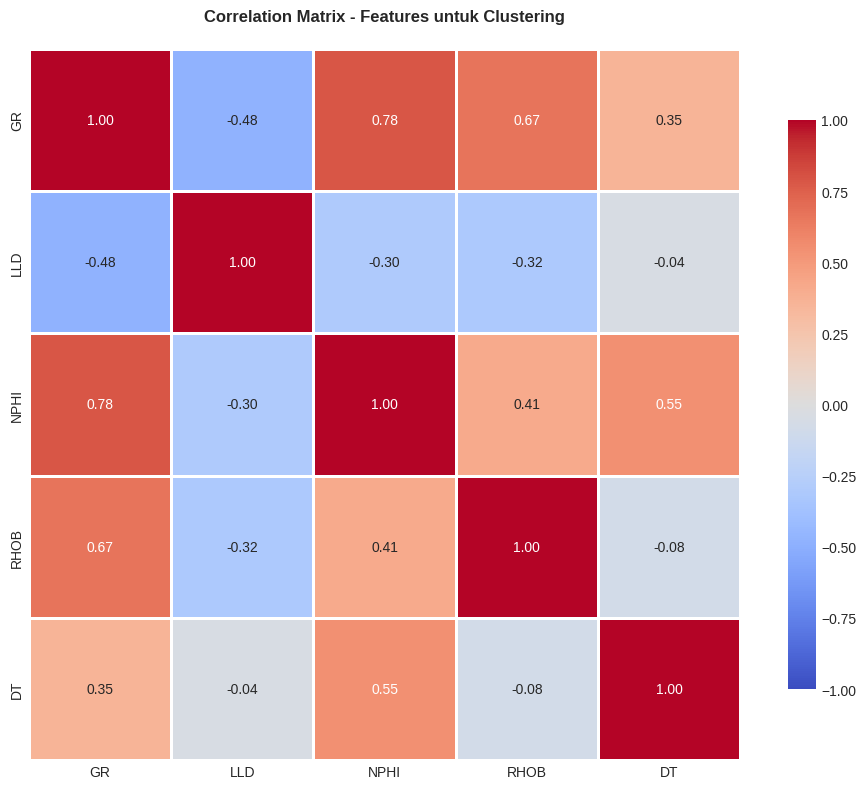


Pasangan features dengan korelasi tinggi (|r| > 0.8):
  Tidak ada korelasi tinggi yang terdeteksi.


In [ ]:
# Hitung correlation matrix
correlation_matrix = df_features_clean[feature_columns].corr()

# Visualisasi heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix - Features untuk Clustering', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identifikasi korelasi tinggi (>0.8 atau <-0.8)
print("\nPasangan features dengan korelasi tinggi (|r| > 0.8):")
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr.append((correlation_matrix.columns[i],
                            correlation_matrix.columns[j],
                            correlation_matrix.iloc[i, j]))

if high_corr:
    for feat1, feat2, corr_val in high_corr:
        print(f"  {feat1} vs {feat2}: {corr_val:.3f}")
else:
    print("  Tidak ada korelasi tinggi yang terdeteksi.")

### 💡 **Interpretasi Korelasi:**
- **GR vs NPHI**: Korelasi positif menunjukkan zona shale memiliki GR tinggi dan NPHI tinggi (clay-bound water)
- **RHOB vs DT**: Korelasi negatif menunjukkan batuan padat (density tinggi) memiliki sonic travel time rendah
- Jika ada features dengan korelasi >0.8, pertimbangkan untuk menghapus salah satunya

### 4.3 Feature Scaling (Standardization)

K-means sangat sensitif terhadap skala data. Kita perlu melakukan standardization (mean=0, std=1).

In [ ]:
# Pisahkan features dan depth
X = df_features_clean[feature_columns].values
depths = df_features_clean['M__DEPTH'].values

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Buat dataframe untuk data yang sudah di-scale
df_scaled = pd.DataFrame(X_scaled, columns=feature_columns, index=df_features_clean.index)

print("Data sebelum scaling:")
print(df_features_clean[feature_columns].describe().loc[['mean', 'std']])
print("\nData setelah scaling:")
print(df_scaled.describe().loc[['mean', 'std']])

print("\n✓ Feature scaling selesai!")

Data sebelum scaling:
             GR        LLD       NPHI      RHOB          DT
mean  82.514141  14.689428  32.706640  2.466475  101.871318
std   18.485676   7.426225   5.968174  0.063220    8.346822

Data setelah scaling:
                GR           LLD          NPHI          RHOB            DT
mean -5.518779e-16 -2.571249e-16  1.003414e-16 -2.508536e-17 -2.508536e-16
std   1.000442e+00  1.000442e+00  1.000442e+00  1.000442e+00  1.000442e+00

✓ Feature scaling selesai!


---
## Part 5: Menentukan Jumlah Cluster Optimal

### 5.1 Elbow Method

Elbow method mencari jumlah cluster dimana penambahan cluster tidak lagi memberikan penurunan signifikan pada **Within-Cluster Sum of Squares (WCSS)**.

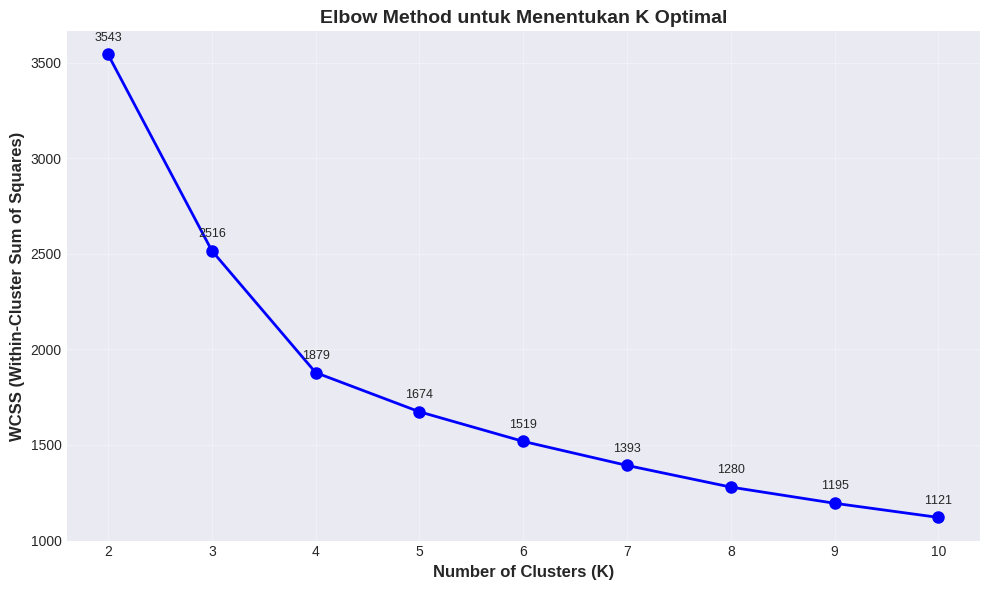


💡 Cari 'elbow' (siku) pada grafik dimana WCSS mulai menurun lebih lambat.


In [ ]:
# Hitung WCSS untuk berbagai nilai K
wcss = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12, fontweight='bold')
plt.title('Elbow Method untuk Menentukan K Optimal', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)

# Tambahkan anotasi
for i, (k, w) in enumerate(zip(K_range, wcss)):
    plt.annotate(f'{w:.0f}', xy=(k, w), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n💡 Cari 'elbow' (siku) pada grafik dimana WCSS mulai menurun lebih lambat.")

### 5.2 Silhouette Score

Silhouette score mengukur seberapa baik sebuah data point cocok dengan cluster-nya dibandingkan cluster lain. Nilai berkisar -1 hingga 1:
- **~1**: Data point sangat cocok dengan cluster-nya
- **~0**: Data point berada di perbatasan cluster
- **~-1**: Data point mungkin salah cluster

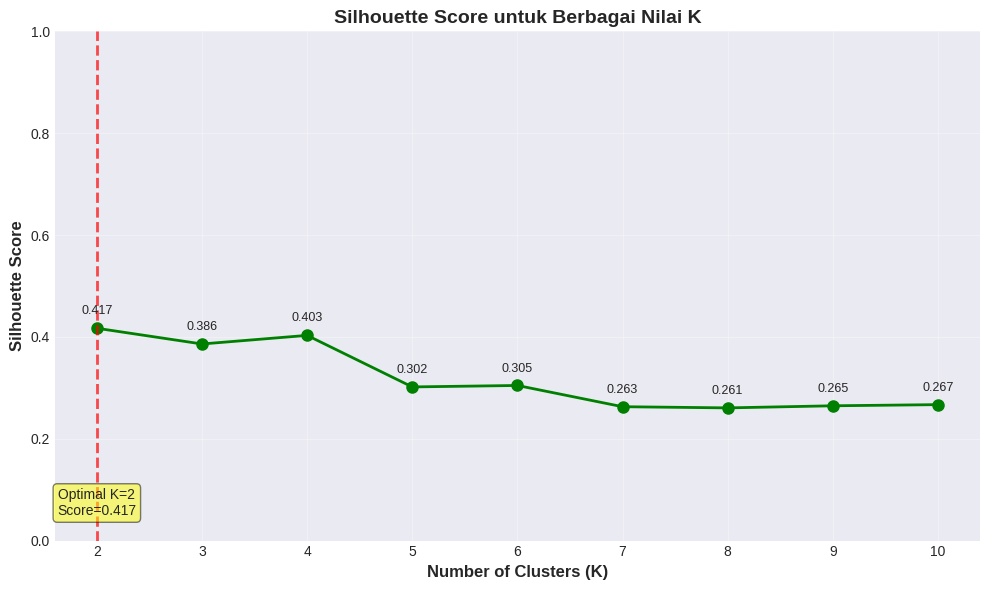


✓ K optimal berdasarkan Silhouette Score: 2 (score: 0.417)


In [ ]:
# Hitung silhouette score untuk berbagai K
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
plt.ylabel('Silhouette Score', fontsize=12, fontweight='bold')
plt.title('Silhouette Score untuk Berbagai Nilai K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.ylim(0, 1)

# Tambahkan anotasi
for i, (k, s) in enumerate(zip(K_range, silhouette_scores)):
    plt.annotate(f'{s:.3f}', xy=(k, s), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9)

# Highlight K optimal
best_k = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
plt.axvline(x=best_k, color='r', linestyle='--', linewidth=2, alpha=0.7)
plt.text(best_k, 0.05, f'Optimal K={best_k}\nScore={best_score:.3f}',
         ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n✓ K optimal berdasarkan Silhouette Score: {best_k} (score: {best_score:.3f})")

### 5.3 Kesimpulan Pemilihan K

Berdasarkan artikel referensi dan analisis di atas, kita akan menggunakan **K=4** clusters untuk analisis selanjutnya.

---
## Part 6: Implementasi K-Means Clustering

### 6.1 Training Model dengan K=4

In [ ]:
# Set optimal K
optimal_k = 4

# Train K-means model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20, max_iter=300)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Tambahkan cluster labels ke dataframe
df_features_clean['Cluster'] = cluster_labels

# Informasi clustering
print(f"Jumlah clusters: {optimal_k}")
print(f"Number of iterations: {kmeans_final.n_iter_}")
print(f"\nDistribusi data per cluster:")
print(df_features_clean['Cluster'].value_counts().sort_index())
print(f"\nPersentase distribusi:")
print((df_features_clean['Cluster'].value_counts(normalize=True).sort_index() * 100).round(2))

Jumlah clusters: 4
Number of iterations: 20

Distribusi data per cluster:
Cluster
0    510
1    186
2    405
3     32
Name: count, dtype: int64

Persentase distribusi:
Cluster
0    45.01
1    16.42
2    35.75
3     2.82
Name: proportion, dtype: float64


### 6.2 Karakteristik Setiap Cluster

Mari kita lihat karakteristik rata-rata setiap cluster.

Rata-rata karakteristik setiap cluster:
            GR    LLD   NPHI  RHOB      DT
Cluster                                   
0        95.91  11.85  37.98  2.48  108.12
1        54.90  16.28  25.68  2.37   98.27
2        81.52  14.71  29.76  2.50   94.93
3        42.16  50.37  26.89  2.35  111.02


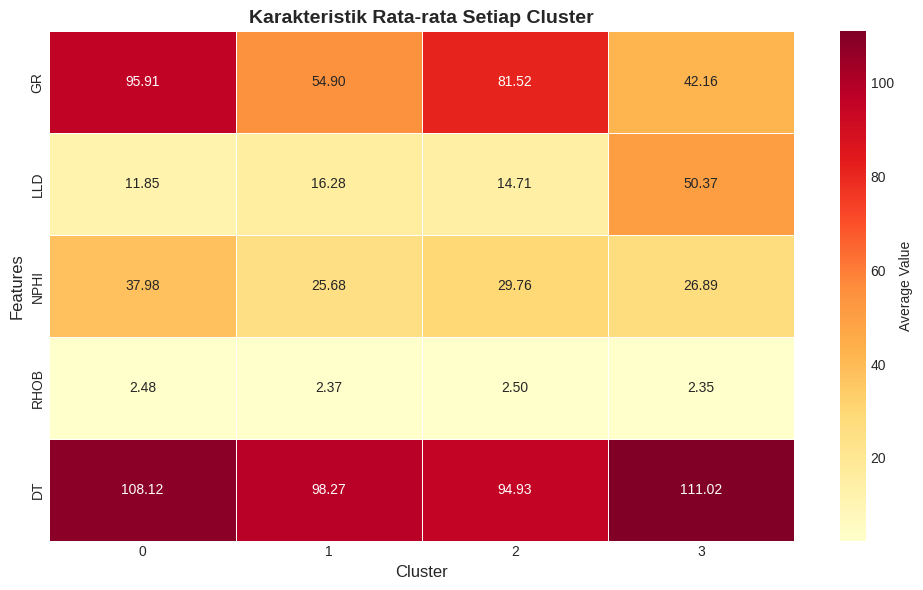

In [ ]:
# Statistik per cluster (data original, bukan scaled)
cluster_stats = df_features_clean.groupby('Cluster')[feature_columns].mean()

print("Rata-rata karakteristik setiap cluster:")
print(cluster_stats.round(2))

# Visualisasi dengan heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_stats.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Average Value'})
plt.title('Karakteristik Rata-rata Setiap Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 7: Visualisasi Hasil Clustering

### 7.1 PCA Visualization (2D)

Karena data kita memiliki 5 dimensi (features), kita gunakan PCA untuk visualisasi 2D.

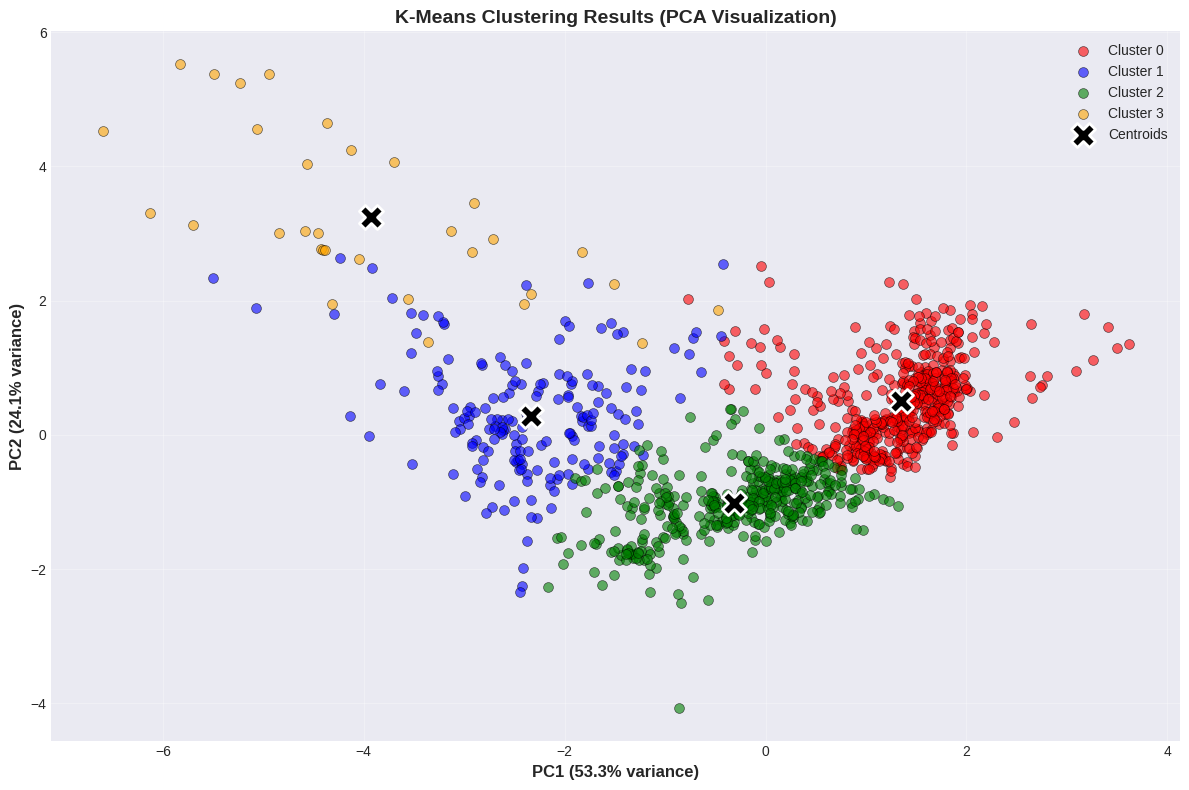


✓ Total variance explained by 2 components: 77.40%


In [ ]:
# PCA untuk reduksi dimensi
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Buat dataframe untuk plotting
df_pca = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': cluster_labels
})

# Plot dengan cluster colors
plt.figure(figsize=(12, 8))

colors = ['red', 'blue', 'green', 'orange']
for cluster in range(optimal_k):
    cluster_data = df_pca[df_pca['Cluster'] == cluster]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'],
               c=colors[cluster], label=f'Cluster {cluster}',
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Plot centroids
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='black', marker='X', s=300, linewidths=2,
           edgecolors='white', label='Centroids', zorder=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)',
          fontsize=12, fontweight='bold')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)',
          fontsize=12, fontweight='bold')
plt.title('K-Means Clustering Results (PCA Visualization)',
         fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Total variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.2f}%")

### 7.2 Box Plots - Cluster vs Features

Visualisasi distribusi setiap feature untuk setiap cluster.

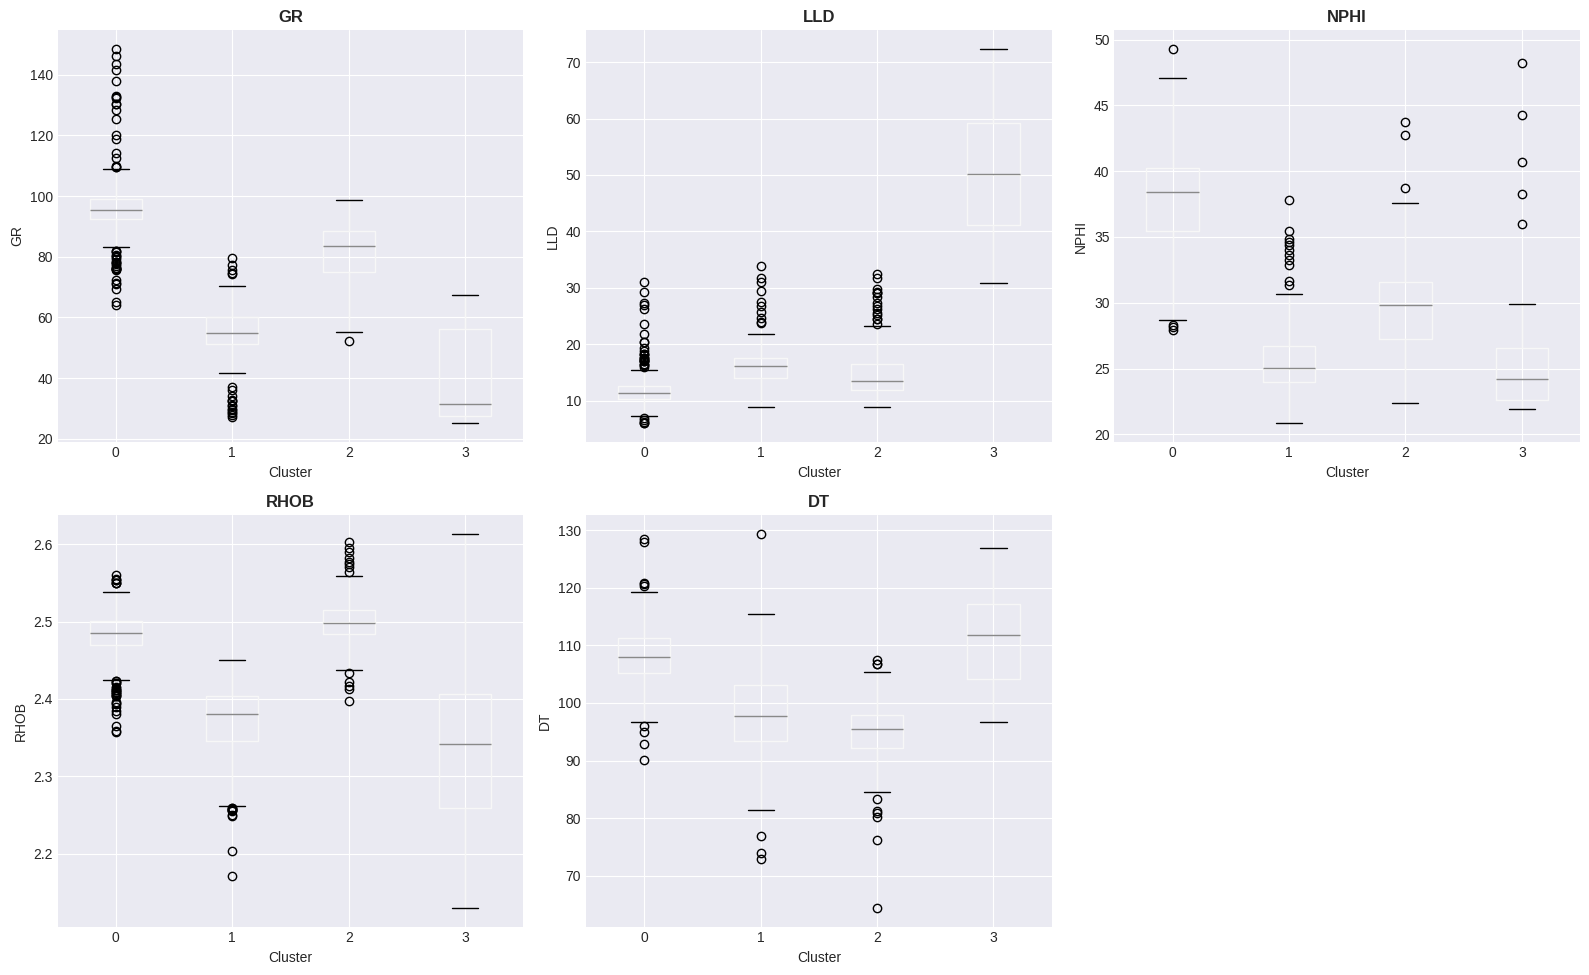

In [ ]:
# Box plots untuk setiap feature
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribusi Features per Cluster', fontsize=14, fontweight='bold', y=1.00)
axes = axes.flatten()

for idx, feature in enumerate(feature_columns):
    df_features_clean.boxplot(column=feature, by='Cluster', ax=axes[idx])
    axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Cluster', fontsize=10)
    axes[idx].set_ylabel(feature, fontsize=10)
    axes[idx].get_figure().suptitle('')  # Remove default title

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

### 7.3 Well Log Display dengan Cluster Track

Visualisasi paling penting: melihat cluster hasil clustering pada well log display.

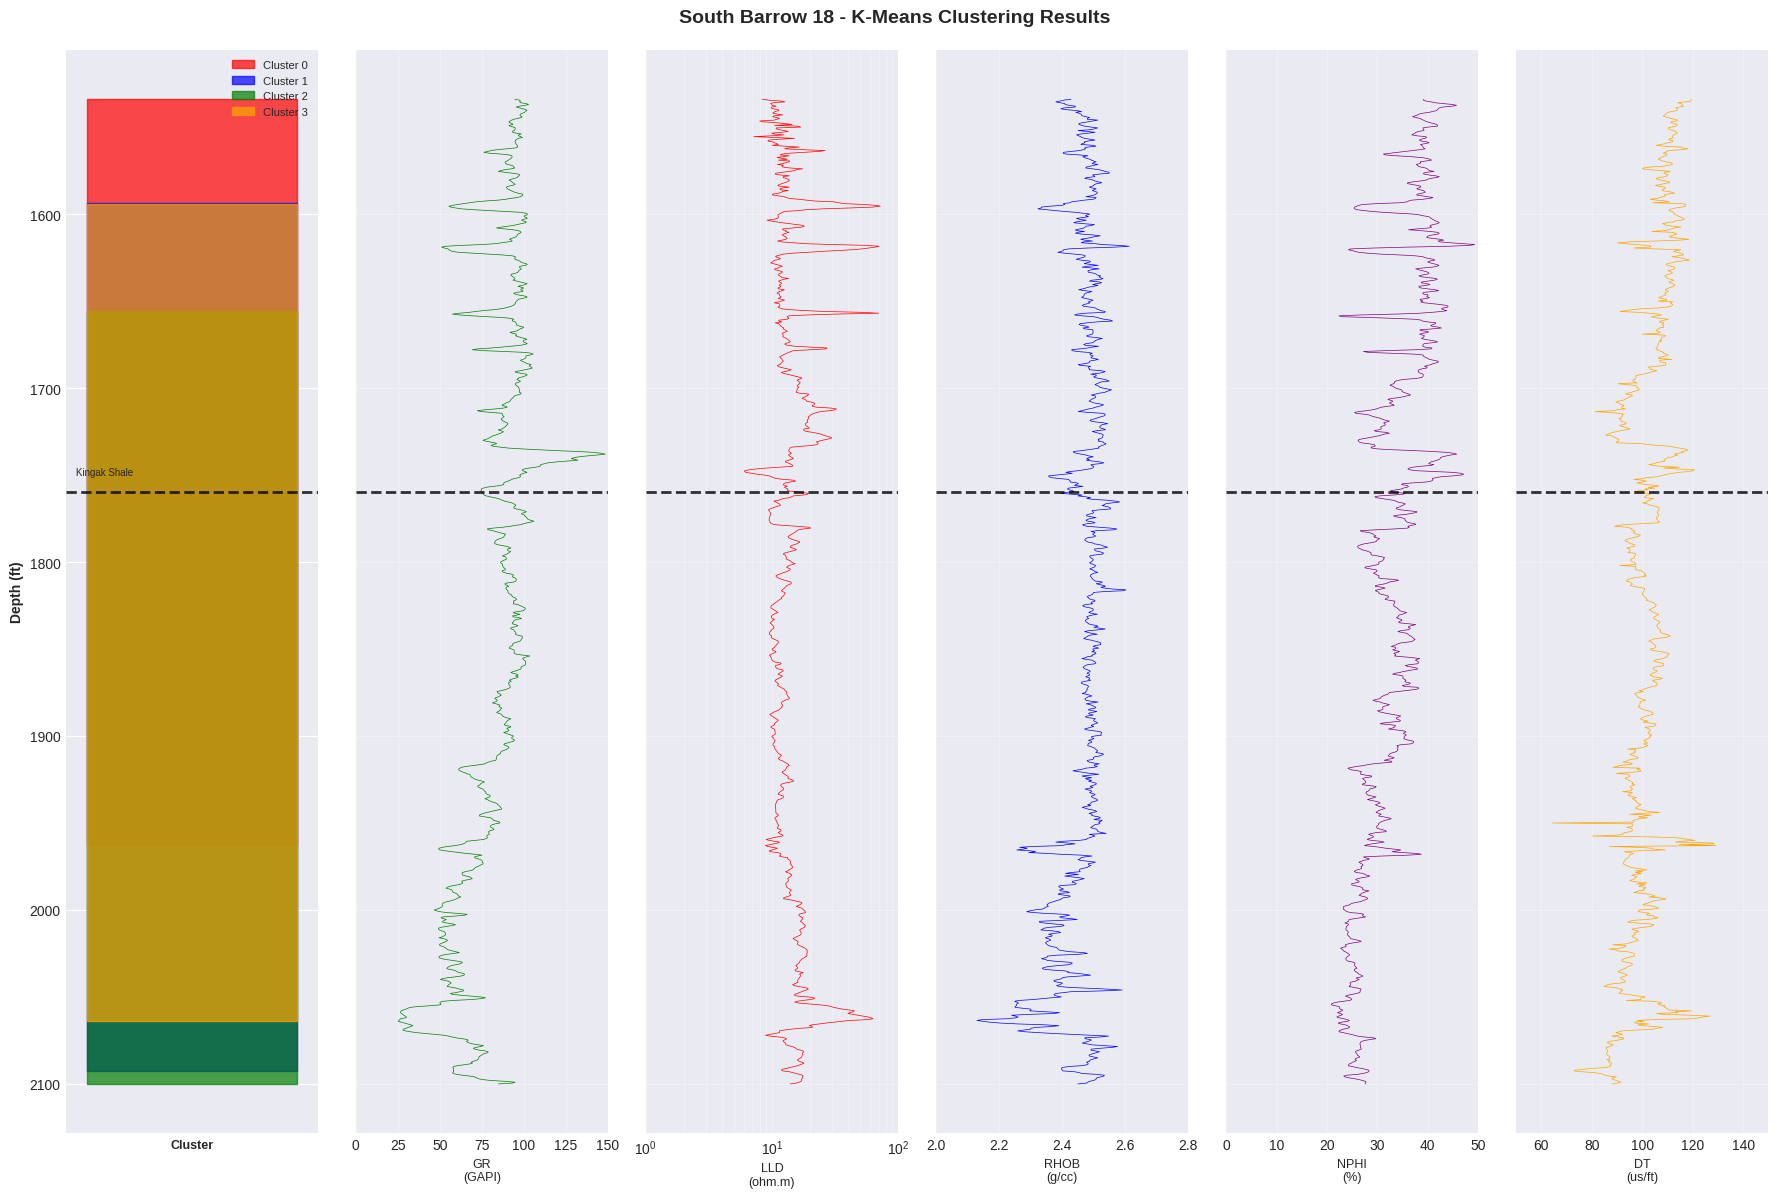


✓ Well log dengan cluster track berhasil divisualisasikan!


In [ ]:
# Merge cluster labels dengan data interval lengkap
df_interval_clustered = df_interval.copy()
df_interval_clustered['Cluster'] = np.nan
df_interval_clustered.loc[df_features_clean.index, 'Cluster'] = df_features_clean['Cluster']

# Create well log display
fig, axes = plt.subplots(1, 6, figsize=(18, 12), sharey=True)
fig.suptitle('South Barrow 18 - K-Means Clustering Results',
            fontsize=14, fontweight='bold', y=0.995)

depth_plot = df_interval_clustered['M__DEPTH']

# Track 1: Cluster
cluster_colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'orange'}
for cluster in range(optimal_k):
    mask = df_interval_clustered['Cluster'] == cluster
    axes[0].fill_betweenx(depth_plot[mask], 0, 1,
                          color=cluster_colors[cluster],
                          label=f'Cluster {cluster}', alpha=0.7)
axes[0].set_xlabel('Cluster', fontsize=9, fontweight='bold')
axes[0].set_xlim(-0.1, 1.1)
axes[0].set_ylabel('Depth (ft)', fontsize=10, fontweight='bold')
axes[0].invert_yaxis()
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_xticks([])

# Track 2: Gamma Ray
axes[1].plot(df_interval_clustered['GR'], depth_plot, 'g-', linewidth=0.5)
axes[1].set_xlabel('GR\n(GAPI)', fontsize=9)
axes[1].set_xlim(0, 150)
axes[1].grid(True, alpha=0.3)

# Track 3: Resistivity
axes[2].semilogx(df_interval_clustered['LLD'], depth_plot, 'r-', linewidth=0.5)
axes[2].set_xlabel('LLD\n(ohm.m)', fontsize=9)
axes[2].set_xlim(1, 100)
axes[2].grid(True, alpha=0.3, which='both')

# Track 4: Density
axes[3].plot(df_interval_clustered['RHOB'], depth_plot, 'b-', linewidth=0.5)
axes[3].set_xlabel('RHOB\n(g/cc)', fontsize=9)
axes[3].set_xlim(2.0, 2.8)
axes[3].grid(True, alpha=0.3)

# Track 5: Neutron
axes[4].plot(df_interval_clustered['NPHI'], depth_plot, 'purple', linewidth=0.5)
axes[4].set_xlabel('NPHI\n(%)', fontsize=9)
axes[4].set_xlim(0, 50)
axes[4].grid(True, alpha=0.3)

# Track 6: Sonic
axes[5].plot(df_interval_clustered['DT'], depth_plot, 'orange', linewidth=0.5)
axes[5].set_xlabel('DT\n(us/ft)', fontsize=9)
axes[5].set_xlim(50, 150)
axes[5].grid(True, alpha=0.3)

# Tambahkan formation tops yang relevan
relevant_tops = df_tops[df_tops['Depth_ft'] >= depth_min]
for idx, row in relevant_tops.iterrows():
    for ax in axes:
        ax.axhline(y=row['Depth_ft'], color='black', linestyle='--',
                  linewidth=2, alpha=0.8)
    axes[0].text(-0.05, row['Depth_ft'] - 10, row['Formation'],
                fontsize=7, rotation=0, ha='left')

plt.tight_layout()
plt.show()

print("\n✓ Well log dengan cluster track berhasil divisualisasikan!")

---
## Part 8: Interpretasi Geologi

### 8.1 Analisis Karakteristik Cluster vs Kedalaman

<Figure size 1000x600 with 0 Axes>

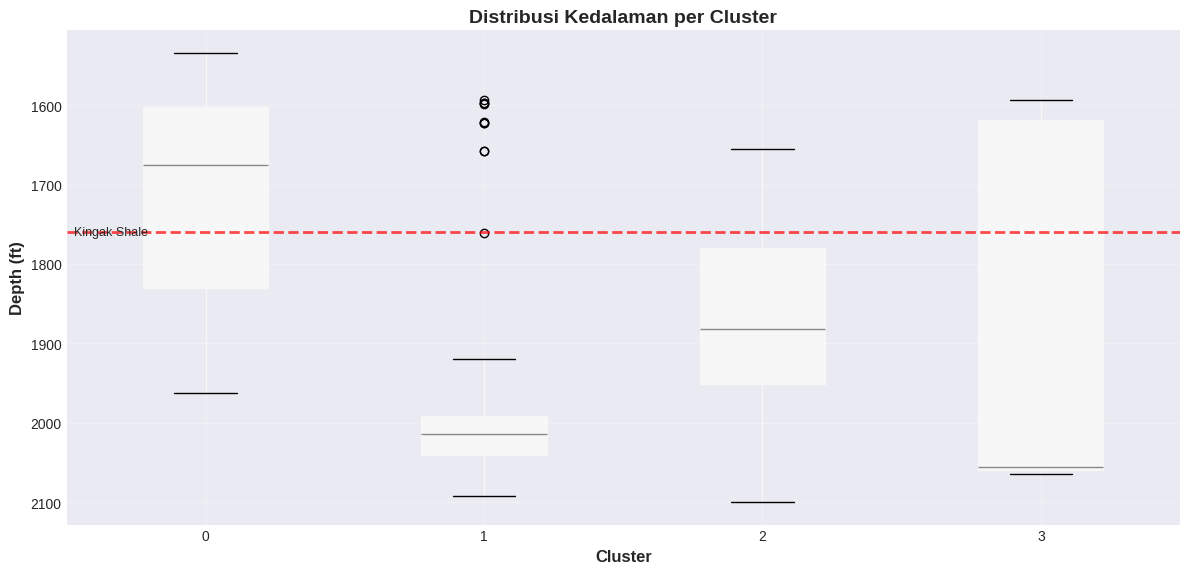


Rata-rata kedalaman per cluster:
            min     max    mean  count
Cluster                               
0        1534.0  1962.0  1704.7    510
1        1593.5  2092.5  1997.9    186
2        1655.5  2100.0  1872.7    405
3        1594.0  2064.0  1851.3     32


In [ ]:
# Box plot: Cluster vs Depth
plt.figure(figsize=(10, 6))
df_features_clean.boxplot(column='M__DEPTH', by='Cluster', patch_artist=True)
plt.title('Distribusi Kedalaman per Cluster', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove default title
plt.xlabel('Cluster', fontsize=12, fontweight='bold')
plt.ylabel('Depth (ft)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()

# Tambahkan formation tops
for idx, row in relevant_tops.iterrows():
    plt.axhline(y=row['Depth_ft'], color='red', linestyle='--',
               linewidth=2, alpha=0.7)
    plt.text(0.5, row['Depth_ft'], f"  {row['Formation']}",
            fontsize=9, va='center')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistik depth per cluster
print("\nRata-rata kedalaman per cluster:")
depth_stats = df_features_clean.groupby('Cluster')['M__DEPTH'].agg(['min', 'max', 'mean', 'count'])
print(depth_stats.round(1))

### 8.2 Interpretasi Fasies Litologi

Berdasarkan karakteristik log dan informasi geologi dari artikel:

In [ ]:
# Interpretasi fasies
facies_interpretation = {
    'Cluster': [0, 1, 2, 3],
    'Kemungkinan_Fasies': [
        'Zona Hidrokarbon / Clean Sandstone',
        'Pebble Shale Unit (Shaly)',
        'Kingak Shale',
        'Barrow Sandstone (Clean Sand)'
    ],
    'Karakteristik': [
        'GR rendah, Resistivity tinggi, NPHI rendah, RHOB rendah',
        'GR tinggi, Resistivity rendah, NPHI tinggi',
        'GR sedang-tinggi, Resistivity sedang',
        'GR rendah, Resistivity sedang-tinggi, NPHI rendah'
    ]
}

df_interpretation = pd.DataFrame(facies_interpretation)
print("\n📊 INTERPRETASI FASIES LITOLOGI:")
print("="*80)
for idx, row in df_interpretation.iterrows():
    print(f"\nCluster {row['Cluster']}: {row['Kemungkinan_Fasies']}")
    print(f"  → {row['Karakteristik']}")
print("="*80)


📊 INTERPRETASI FASIES LITOLOGI:

Cluster 0: Zona Hidrokarbon / Clean Sandstone
  → GR rendah, Resistivity tinggi, NPHI rendah, RHOB rendah

Cluster 1: Pebble Shale Unit (Shaly)
  → GR tinggi, Resistivity rendah, NPHI tinggi

Cluster 2: Kingak Shale
  → GR sedang-tinggi, Resistivity sedang

Cluster 3: Barrow Sandstone (Clean Sand)
  → GR rendah, Resistivity sedang-tinggi, NPHI rendah


### 💡 **Key Insights dari Clustering:**

1. **Cluster 0**: Kemungkinan zona hidrokarbon atau clean sandstone
   - Resistivity tinggi → indikasi HC atau tight rock
   - GR rendah → mineral clay minimal
   - NPHI rendah → porosity terisi gas atau rendah

2. **Cluster 1**: Pebble Shale Unit (zona shaly)
   - GR tinggi → kandungan clay tinggi
   - NPHI tinggi → clay-bound water
   - Korelasi dengan formation tops

3. **Cluster 2**: Kingak Shale
   - Karakteristik intermediate
   - Perselingan shale-siltstone

4. **Cluster 3**: Barrow Sandstone
   - GR rendah → clean sand
   - Resistivity sedang → water-bearing sand
   - Korelasi dengan interval 1976-2072 ft

---
## Part 9: Validasi dengan Silhouette Analysis

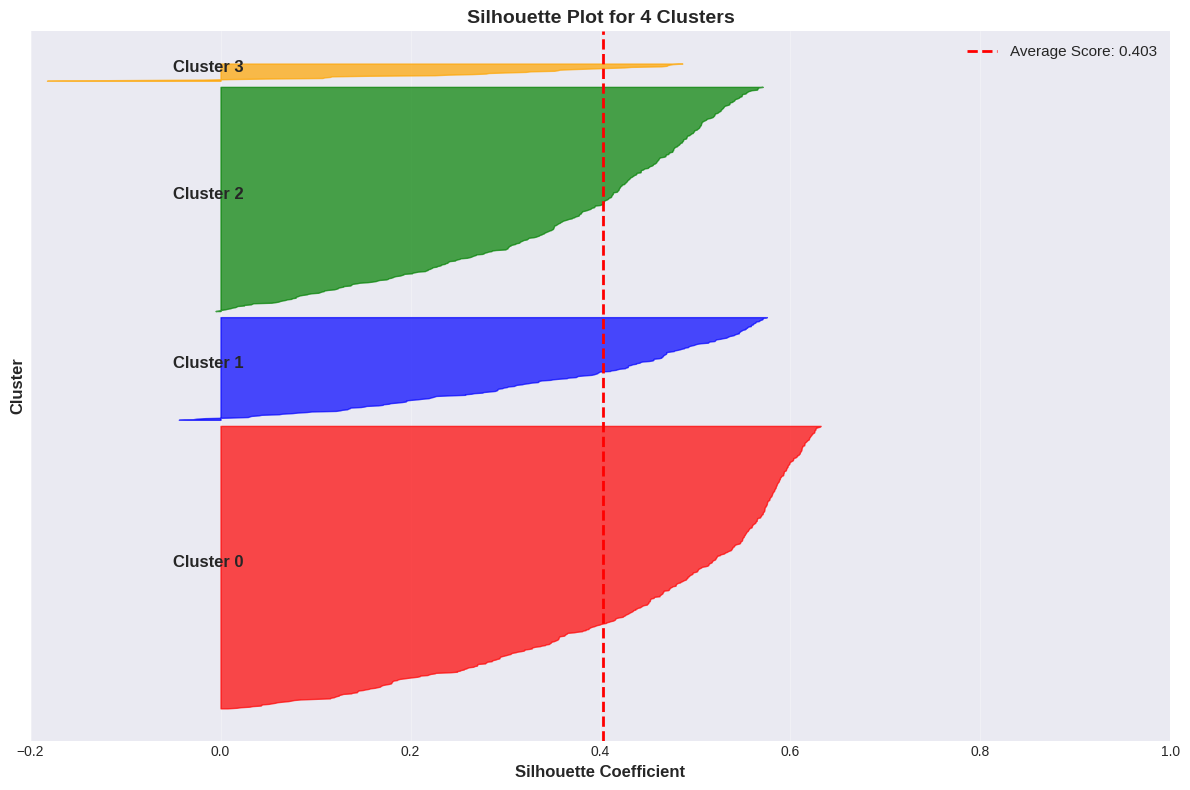


✓ Average Silhouette Score: 0.403

💡 Interpretasi:
  - Nilai > 0.5: Clustering sangat baik
  - Nilai 0.25-0.5: Clustering cukup baik
  - Nilai < 0.25: Clustering kurang optimal


In [ ]:
# Hitung silhouette values untuk setiap sample
silhouette_vals = silhouette_samples(X_scaled, cluster_labels)
avg_silhouette = silhouette_score(X_scaled, cluster_labels)

# Silhouette plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

y_lower = 10
for i in range(optimal_k):
    # Ambil silhouette values untuk cluster i
    cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
    cluster_silhouette_vals.sort()

    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cluster_colors[i]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)

    # Label cluster
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, f'Cluster {i}',
           fontsize=12, fontweight='bold')

    y_lower = y_upper + 10

# Average silhouette score line
ax.axvline(x=avg_silhouette, color="red", linestyle="--", linewidth=2,
          label=f'Average Score: {avg_silhouette:.3f}')

ax.set_xlabel('Silhouette Coefficient', fontsize=12, fontweight='bold')
ax.set_ylabel('Cluster', fontsize=12, fontweight='bold')
ax.set_title(f'Silhouette Plot for {optimal_k} Clusters',
            fontsize=14, fontweight='bold')
ax.set_xlim([-0.2, 1])
ax.set_yticks([])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\n✓ Average Silhouette Score: {avg_silhouette:.3f}")
print("\n💡 Interpretasi:")
print("  - Nilai > 0.5: Clustering sangat baik")
print("  - Nilai 0.25-0.5: Clustering cukup baik")
print("  - Nilai < 0.25: Clustering kurang optimal")

---
## Part 10: Export Hasil Clustering

In [ ]:
# Export hasil clustering ke CSV
output_file = 'SB18_clustering_results.csv'
df_features_clean.to_csv(output_file, index=False)
print(f"✓ Hasil clustering disimpan ke: {output_file}")

# Summary statistics per cluster
summary_file = 'SB18_cluster_summary.csv'
cluster_summary = df_features_clean.groupby('Cluster')[feature_columns].agg(['mean', 'std', 'min', 'max'])
cluster_summary.to_csv(summary_file)
print(f"✓ Summary statistik disimpan ke: {summary_file}")

✓ Hasil clustering disimpan ke: SB18_clustering_results.csv
✓ Summary statistik disimpan ke: SB18_cluster_summary.csv


---
## 🎯 Latihan Mandiri

### Latihan 1: Eksplorasi Jumlah Cluster Berbeda
Coba lakukan clustering dengan K=3 atau K=5. Bandingkan hasilnya dengan K=4:
- Bagaimana interpretasi fasies berubah?
- Cluster mana yang terpecah atau tergabung?
- Mana yang lebih make sense secara geologi?

```python
# Tulis kode Anda di sini
```

### Latihan 2: Feature Selection
Coba lakukan clustering hanya dengan 3 features (misal: GR, LLD, NPHI):
- Apakah hasilnya berbeda signifikan?
- Features mana yang paling berpengaruh?

```python
# Tulis kode Anda di sini
```

### Latihan 3: Clustering pada Interval Berbeda
Coba clustering pada interval yang berbeda (misalnya di Pebble Shale Unit saja: 1375-1760 ft):
- Apakah bisa mengidentifikasi sub-fasies dalam formasi ini?

```python
# Tulis kode Anda di sini
```


---
## 📚 Kesimpulan

### Yang Sudah Dipelajari:
1. ✅ Konsep unsupervised learning dan K-means clustering
2. ✅ Loading dan preprocessing data well log (LAS format)
3. ✅ Feature scaling dan correlation analysis
4. ✅ Menentukan K optimal dengan elbow method dan silhouette score
5. ✅ Implementasi K-means clustering
6. ✅ Visualisasi hasil (PCA, well log display, box plots)
7. ✅ Interpretasi geologi dan validasi dengan formation tops

### Key Takeaways:
- 🎯 K-means clustering efektif untuk identifikasi fasies litologi otomatis
- 🎯 Preprocessing (scaling, handling missing values) sangat penting
- 🎯 Selalu validasi hasil dengan ground truth (core, formation tops)
- 🎯 Domain knowledge geologi tetap essential untuk interpretasi
- 🎯 Clustering adalah alat bantu, bukan pengganti interpretasi ahli

### Best Practices:
1. **Pisahkan zona hidrokarbon dan non-hidrokarbon** jika tujuan utama adalah fasies litologi
2. **Lakukan clustering per formasi** untuk hasil lebih detail
3. **Selalu cek korelasi antar features** untuk avoid multicollinearity
4. **Validasi dengan multiple metrics** (elbow, silhouette, domain knowledge)
5. **Dokumentasikan asumsi dan interpretasi** untuk reproducibility

---

### 🔗 Referensi:
- [Artikel Medium - K-means Clustering pada Data Well Log](https://medium.com/sedstrat/k-means-clustering-pada-data-well-log-2f9c52cb3693)
- [USGS Open File Report 00-200](https://certmapper.cr.usgs.gov/data/PubArchives/OF00-200/WELLS/SBAR18/INDEX.HTM)
- [Scikit-learn Documentation - Clustering](https://scikit-learn.org/stable/modules/clustering.html)
- [UC Business Analytics R Programming Guide - K-means](https://uc-r.github.io/kmeans_clustering)

---

**Selamat! Anda telah menyelesaikan hands-on clustering pada data well log! 🎉**